In [17]:
import torch
import numpy as np
import matplotlib.pyplot as plt
import os
from matplotlib import rc
import matplotlib as mpl
from matplotlib.ticker import MaxNLocator

In [18]:
mpl.rcParams.update(mpl.rcParamsDefault)

rc('font',**{'family':'sans-serif','sans-serif':['Helvetica']})
mpl.rcParams['savefig.dpi'] = 1200
mpl.rcParams['text.usetex'] = True  # not really needed

In [19]:

file = '../results/results_data/dp_users_syn_1000_250_r10_p1e-02.pt'

#results = torch.load(observed_entries_file)
#privacy_tradeoff_results = torch.load(privacy_tradeoff_file)
results = torch.load(file)

/var/folders/2_/r_w1bxyd7yj52gcl_l7jdl2r0000gn/T/ipykernel_33981/1045201138.py:5: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  results = torch.load(file)


[500, 1000, 5000, 10000]
[0.5, 1, 2, 10, 20]
[[1.18788485 1.04831425 1.0084668  0.98602676 0.98528369]
 [1.20758474 1.05050151 0.99763006 0.96953356 0.96907431]
 [1.19406565 0.93751246 0.87754615 0.85943566 0.85886492]
 [1.00526176 0.79374293 0.727717   0.72117567 0.71953094]]
[[1.22415129 1.0608288  1.00382107 0.92049414 0.92052688]
 [1.26298118 1.05967867 0.85722224 0.76003297 0.76748576]
 [1.3670576  0.81985946 0.51462889 0.22125047 0.18939341]
 [1.403754   0.76954385 0.43009194 0.1565788  0.13990037]]
[[1.03053027 1.01193779 0.99539328 0.9335387  0.93427597]
 [1.04587375 1.00873599 0.85925863 0.7839161  0.79197823]
 [1.14487642 0.87450514 0.58644082 0.25743692 0.22051594]
 [1.39640644 0.96951269 0.59101538 0.21711604 0.19443274]]


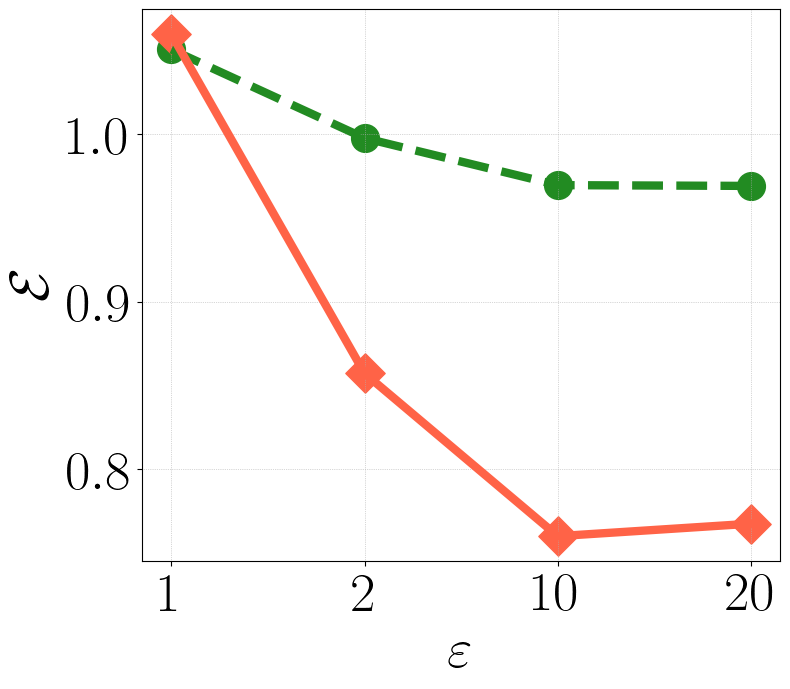

[0 1 2 3]


In [20]:
# observed entries
title = r'$\mathrm{Synthetic}~(p = 0.01)$'
#X = np.array([1000, 2000, 6000, 10000, 20000, 50000])
X = results['user_list']
epsilon_list = results['epsilon_list']
print(X)
print(epsilon_list)
"""
original_err_mean = results['original_err_mean']
original_err_std = results['original_err_std']
T_prob_err_mean = results['T_prob_err_mean']
T_prob_err_std = results['T_prob_err_std']
T_freq_err_mean = results['T_freq_err_mean']
T_freq_err_std = results['T_freq_err_std']
SVD_T_err_mean = results['SVD_T_err_mean']
SVD_T_err_std = results['SVD_T_err_std']
X_original_err_mean = results['X_original_err_mean']
X_original_err_std = results['X_original_err_std']
ob2_err_mean = results['ob2_err_mean']
ob2_rmse_mean = results['ob2_rmse_mean']
"""
ob2_err_mean = results['ob2_err_mean'].reshape(len(X), len(epsilon_list))
err_mean = results['err_mean'].reshape(len(X), len(epsilon_list))
err_std = results['err_std'].reshape(len(X), len(epsilon_list))
#rmse_mean = results['rmse_mean']
#rmse_std = results['rmse_std'] 
plt.figure(figsize=(8,7))
#plt.plot(X, original_err_mean, lw=4, label=r"$\tilde{M}^T\tilde{M}$")
#plt.plot(X, T_prob_err_mean, lw=4, label=r"$T_{\text{prob}}$")
#plt.plot(X, T_freq_err_mean, lw=4, label=r"$T_{\text{freq}}$")
#plt.plot(X, SVD_T_err_mean, lw=4, label=r"$\mathrm{SVD}$")
print(ob2_err_mean)
print(err_mean)
enhance = (err_mean / ob2_err_mean)
print(enhance)
#plt.plot(epsilon_list, ob2_err_mean[0], lw=4,linestyle='-.')
# plt.plot(epsilon_list, ob2_err_mean[1], lw=4,linestyle='-.')
i = 1
x_list = np.arange(len(epsilon_list[1:]))
plt.plot(x_list, ob2_err_mean[i][1:], color = "forestgreen", lw=6,linestyle='dashed')

#plt.scatter(epsilon_list, ob2_err_mean[0], lw=4,linestyle='-.', label=r"$\|\cdot\|_\star~~\mathrm{reg.},~d_1=500$")
# plt.scatter(epsilon_list, ob2_err_mean[1], lw=4,linestyle='-.', label=r"$\|\cdot\|_\star~~\mathrm{reg.},~d_1=1000$")
plt.scatter(x_list, ob2_err_mean[i][1:], color = "forestgreen", s=400, label=r"$\mathrm{Nuclear~norm}$"+"\n"+r"$\mathrm{regularization}$")

#plt.plot(epsilon_list, err_mean[0], lw=4)
# plt.plot(epsilon_list, err_mean[1], lw=4)
plt.plot(x_list, err_mean[i][1:], color='tomato', lw=6)

#plt.scatter(epsilon_list, ob2_err_mean[2], s=200,linestyle='-.', label=r"$\|\cdot\|_\star~~\mathrm{reg.},~\epsilon=20$")
#plt.scatter(epsilon_list, err_mean[0], s=200, label=r"$\mathrm{Ours},~d_1=500$")
# plt.scatter(epsilon_list, err_mean[1], s=200, label=r"$\mathrm{Ours},~d_1=1000$")
plt.scatter(x_list, err_mean[i][1:], s=400, color='tomato',marker="D", label=r"$\mathrm{Alg.~1}$")



#plt.legend(fontsize=20, loc='upper center',bbox_to_anchor=(0.5, 1.4), ncol=2)
#plt.title(title, fontsize=40, y=1.4)
# plt.title(title, fontsize=40)
#plt.legend(fontsize=20, loc='center left',bbox_to_anchor=(1, 0.5), ncol=1)
#plt.legend(fontsize=30, loc='center right', ncol=1)

plt.xlabel(r"$\varepsilon$", fontsize=40)
plt.ylabel(r"$\mathcal{E}$", fontsize=40)

plt.xticks(x_list, [r"$1$", r"$2$", r"$10$", r"$20$"], fontsize=40)
plt.yticks(fontsize=40)
# plt.xlim(-0.5, 4)

#plt.yscale("log", base=10)
#plt.ylim(,1.1)
#plt.ticklabel_format(style='sci', axis='x', scilimits=(4, 4))
#plt.gca().xaxis.get_offset_text().set_fontsize(40)  

# plt.gca().xaxis.set_major_locator(MaxNLocator(6))
plt.gca().yaxis.set_major_locator(MaxNLocator(4))
plt.grid(lw=0.5, ls=":")
#acc_str = f"best train acc: {np.array(train_acc).max():.4f}\nvalid acc: {val_acc[-1]:.4f}\nbest valid acc: {np.array(val_acc).max():.4f}\ngrokking gap: {val_converge-train_converge}"
# plt.annotate(acc_str, xy=(0.2, 0.5), xycoords='axes fraction', fontsize=12, color='purple', ha='center')
# add the annotation text to the overleaf file
plt.tight_layout()
plot_name = f"./plots/users_dp_1000_p2_err.pdf"
plt.savefig(plot_name, bbox_inches='tight', format="pdf", dpi=1200)

plt.show()
plt.close()
print(x_list)

[500, 1000, 5000, 10000]
[0.5, 1, 2, 10, 20]
[[1.18788485 1.04831425 1.0084668  0.98602676 0.98528369]
 [1.20758474 1.05050151 0.99763006 0.96953356 0.96907431]
 [1.19406565 0.93751246 0.87754615 0.85943566 0.85886492]
 [1.00526176 0.79374293 0.727717   0.72117567 0.71953094]]
[[1.22415129 1.0608288  1.00382107 0.92049414 0.92052688]
 [1.26298118 1.05967867 0.85722224 0.76003297 0.76748576]
 [1.3670576  0.81985946 0.51462889 0.22125047 0.18939341]
 [1.403754   0.76954385 0.43009194 0.1565788  0.13990037]]
[[1.03053027 1.01193779 0.99539328 0.9335387  0.93427597]
 [1.04587375 1.00873599 0.85925863 0.7839161  0.79197823]
 [1.14487642 0.87450514 0.58644082 0.25743692 0.22051594]
 [1.39640644 0.96951269 0.59101538 0.21711604 0.19443274]]


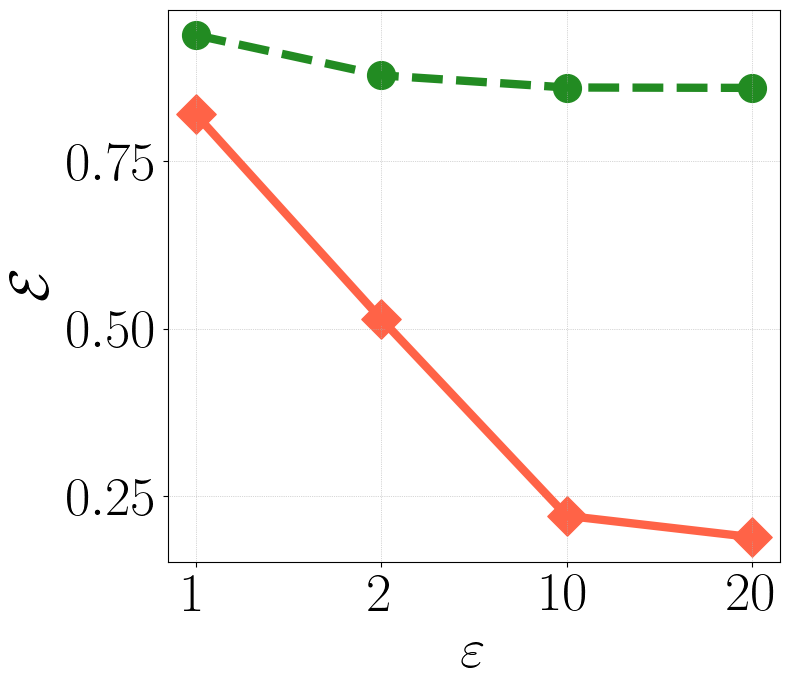

[0 1 2 3]


In [21]:
# observed entries
title = r'$\mathrm{Synthetic}~(p = 0.01)$'
#X = np.array([1000, 2000, 6000, 10000, 20000, 50000])
X = results['user_list']
epsilon_list = results['epsilon_list']
print(X)
print(epsilon_list)
"""
original_err_mean = results['original_err_mean']
original_err_std = results['original_err_std']
T_prob_err_mean = results['T_prob_err_mean']
T_prob_err_std = results['T_prob_err_std']
T_freq_err_mean = results['T_freq_err_mean']
T_freq_err_std = results['T_freq_err_std']
SVD_T_err_mean = results['SVD_T_err_mean']
SVD_T_err_std = results['SVD_T_err_std']
X_original_err_mean = results['X_original_err_mean']
X_original_err_std = results['X_original_err_std']
ob2_err_mean = results['ob2_err_mean']
ob2_rmse_mean = results['ob2_rmse_mean']
"""
ob2_err_mean = results['ob2_err_mean'].reshape(len(X), len(epsilon_list))
err_mean = results['err_mean'].reshape(len(X), len(epsilon_list))
err_std = results['err_std'].reshape(len(X), len(epsilon_list))
#rmse_mean = results['rmse_mean']
#rmse_std = results['rmse_std'] 
plt.figure(figsize=(8,7))
#plt.plot(X, original_err_mean, lw=4, label=r"$\tilde{M}^T\tilde{M}$")
#plt.plot(X, T_prob_err_mean, lw=4, label=r"$T_{\text{prob}}$")
#plt.plot(X, T_freq_err_mean, lw=4, label=r"$T_{\text{freq}}$")
#plt.plot(X, SVD_T_err_mean, lw=4, label=r"$\mathrm{SVD}$")
print(ob2_err_mean)
print(err_mean)
enhance = (err_mean / ob2_err_mean)
print(enhance)
#plt.plot(epsilon_list, ob2_err_mean[0], lw=4,linestyle='-.')
# plt.plot(epsilon_list, ob2_err_mean[1], lw=4,linestyle='-.')
i = 2
x_list = np.arange(len(epsilon_list[1:]))
plt.plot(x_list, ob2_err_mean[i][1:], color = "forestgreen", lw=6,linestyle='dashed')

#plt.scatter(epsilon_list, ob2_err_mean[0], lw=4,linestyle='-.', label=r"$\|\cdot\|_\star~~\mathrm{reg.},~d_1=500$")
# plt.scatter(epsilon_list, ob2_err_mean[1], lw=4,linestyle='-.', label=r"$\|\cdot\|_\star~~\mathrm{reg.},~d_1=1000$")
plt.scatter(x_list, ob2_err_mean[i][1:], color = "forestgreen", s=400, label=r"$\mathrm{Nuclear~norm}$"+"\n"+r"$\mathrm{regularization}$")

#plt.plot(epsilon_list, err_mean[0], lw=4)
# plt.plot(epsilon_list, err_mean[1], lw=4)
plt.plot(x_list, err_mean[i][1:], color='tomato', lw=6)

#plt.scatter(epsilon_list, ob2_err_mean[2], s=200,linestyle='-.', label=r"$\|\cdot\|_\star~~\mathrm{reg.},~\epsilon=20$")
#plt.scatter(epsilon_list, err_mean[0], s=200, label=r"$\mathrm{Ours},~d_1=500$")
# plt.scatter(epsilon_list, err_mean[1], s=200, label=r"$\mathrm{Ours},~d_1=1000$")
plt.scatter(x_list, err_mean[i][1:], s=400, color='tomato',marker="D", label=r"$\mathrm{Alg.~1}$")



#plt.legend(fontsize=20, loc='upper center',bbox_to_anchor=(0.5, 1.4), ncol=2)
#plt.title(title, fontsize=40, y=1.4)
# plt.title(title, fontsize=40)
#plt.legend(fontsize=20, loc='center left',bbox_to_anchor=(1, 0.5), ncol=1)
#plt.legend(fontsize=30, loc='center right', ncol=1)

plt.xlabel(r"$\varepsilon$", fontsize=40)
plt.ylabel(r"$\mathcal{E}$", fontsize=40)

plt.xticks(x_list, [r"$1$", r"$2$", r"$10$", r"$20$"], fontsize=40)
plt.yticks(fontsize=40)
# plt.xlim(-0.5, 4)

#plt.yscale("log", base=10)
#plt.ylim(,1.1)
#plt.ticklabel_format(style='sci', axis='x', scilimits=(4, 4))
#plt.gca().xaxis.get_offset_text().set_fontsize(40)  

# plt.gca().xaxis.set_major_locator(MaxNLocator(6))
plt.gca().yaxis.set_major_locator(MaxNLocator(4))
plt.grid(lw=0.5, ls=":")
#acc_str = f"best train acc: {np.array(train_acc).max():.4f}\nvalid acc: {val_acc[-1]:.4f}\nbest valid acc: {np.array(val_acc).max():.4f}\ngrokking gap: {val_converge-train_converge}"
# plt.annotate(acc_str, xy=(0.2, 0.5), xycoords='axes fraction', fontsize=12, color='purple', ha='center')
# add the annotation text to the overleaf file
plt.tight_layout()
plot_name = f"./plots/users_dp_5000_p2_err.pdf"
plt.savefig(plot_name, bbox_inches='tight', format="pdf", dpi=1200)

plt.show()
plt.close()
print(x_list)

[500, 1000, 5000, 10000]
[0.5, 1, 2, 10, 20]


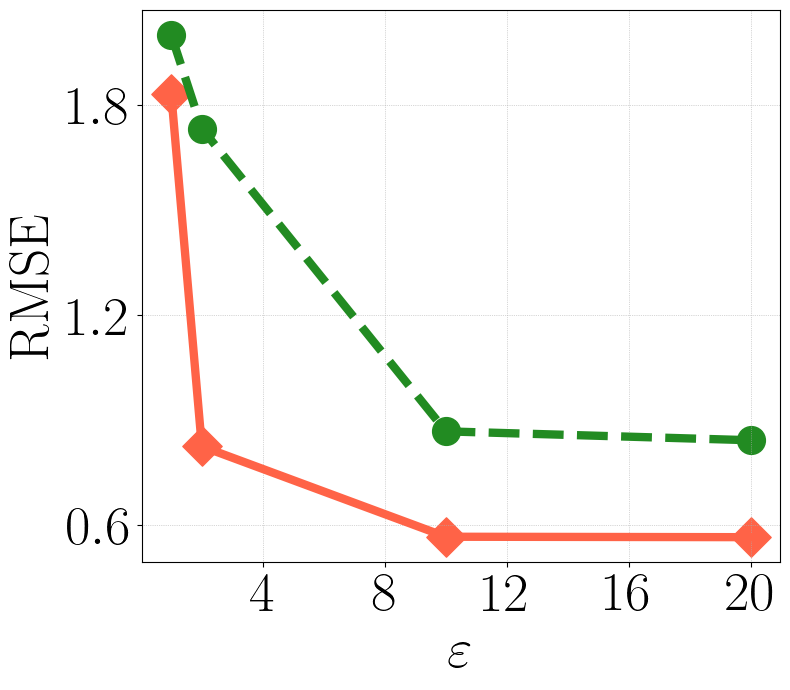

In [24]:
# observed entries
title = r'$\mathrm{Synthetic}~(p = 0.01)$'
#X = np.array([1000, 2000, 6000, 10000, 20000, 50000])
X = results['user_list']
epsilon_list = results['epsilon_list']
print(X)
print(epsilon_list)
"""
original_err_mean = results['original_err_mean']
original_err_std = results['original_err_std']
T_prob_err_mean = results['T_prob_err_mean']
T_prob_err_std = results['T_prob_err_std']
T_freq_err_mean = results['T_freq_err_mean']
T_freq_err_std = results['T_freq_err_std']
SVD_T_err_mean = results['SVD_T_err_mean']
SVD_T_err_std = results['SVD_T_err_std']
X_original_err_mean = results['X_original_err_mean']
X_original_err_std = results['X_original_err_std']
ob2_err_mean = results['ob2_err_mean']
ob2_rmse_mean = results['ob2_rmse_mean']
"""
rmse_mean = results['rmse_mean'].reshape(len(X), len(epsilon_list))
rmse_std = results['rmse_std'].reshape(len(X), len(epsilon_list))
ob2_err_mean = results['ob2_err_mean'].reshape(len(X), len(epsilon_list))
ob2_rmse_mean = results['ob2_rmse_mean'].reshape(len(X), len(epsilon_list))
err_mean = results['err_mean'].reshape(len(X), len(epsilon_list))
err_std = results['err_std'].reshape(len(X), len(epsilon_list))
#rmse_mean = results['rmse_mean']
#rmse_std = results['rmse_std'] 
plt.figure(figsize=(8,7))
i = 1
#plt.plot(X, original_err_mean, lw=4, label=r"$\tilde{M}^T\tilde{M}$")
#plt.plot(X, T_prob_err_mean, lw=4, label=r"$T_{\text{prob}}$")
#plt.plot(X, T_freq_err_mean, lw=4, label=r"$T_{\text{freq}}$")
#plt.plot(X, SVD_T_err_mean, lw=4, label=r"$\mathrm{SVD}$")
#plt.plot(X, ob2_rmse_mean[0], lw=4,linestyle='-.', label=r"$\|\cdot\|_\star~~\mathrm{reg.},~\epsilon=2$")
# plt.plot(epsilon_list, ob2_rmse_mean[1], lw=4,linestyle='-.')
plt.plot(epsilon_list[1:], ob2_rmse_mean[i][1:], lw=6,  color = "forestgreen",linestyle='dashed')
#plt.plot(X, rmse_mean[0], lw=4)
# plt.plot(epsilon_list, rmse_mean[1], lw=4)
plt.plot(epsilon_list[1:], rmse_mean[i][1:],  color='tomato', lw=6)

# plt.scatter(epsilon_list, ob2_rmse_mean[1], s=200,linestyle='-.', label=r"$\|\cdot\|_\star~~\mathrm{reg.},~d_1=1000$")
plt.scatter(epsilon_list[1:], ob2_rmse_mean[i][1:], s=400, color="forestgreen", label=r"$\mathrm{Nuclear~norm}$"+"\n"+r"$\mathrm{regularization}$")
#plt.scatter(X, rmse_mean[0], s=200, label=r"$\mathrm{Ours},~\epsilon=2$")
# plt.scatter(epsilon_list, rmse_mean[1], s=200, label=r"$\mathrm{Ours},~d_1=1000$")
plt.scatter(epsilon_list[1:], rmse_mean[i][1:], s=400, color='tomato',marker="D", label=r"$\mathrm{Alg.~1}$")


#plt.legend(fontsize=20, loc='upper center',bbox_to_anchor=(0.5, 1.4), ncol=2)
#plt.title(title, fontsize=40, y=1.4)
#plt.title(title, fontsize=40)
#plt.legend(fontsize=20, loc='center left',bbox_to_anchor=(1, 0.5), ncol=1)
#plt.legend(fontsize=30, loc='center right', ncol=1,bbox_to_anchor=(1, 0.4))

plt.xlabel(r"$\varepsilon$", fontsize=40)
plt.ylabel(r"$\mathrm{RMSE}$", fontsize=40)

plt.xticks(fontsize=40)
plt.yticks(fontsize=40)
#plt.yscale("log", base=10)
#plt.ylim(,1.1)
# plt.ticklabel_format(style='sci', axis='x', scilimits=(4, 4))
# plt.gca().xaxis.get_offset_text().set_fontsize(40)  

plt.gca().xaxis.set_major_locator(MaxNLocator(6))
plt.gca().yaxis.set_major_locator(MaxNLocator(3))
plt.grid(lw=0.5, ls=":")
#acc_str = f"best train acc: {np.array(train_acc).max():.4f}\nvalid acc: {val_acc[-1]:.4f}\nbest valid acc: {np.array(val_acc).max():.4f}\ngrokking gap: {val_converge-train_converge}"
# plt.annotate(acc_str, xy=(0.2, 0.5), xycoords='axes fraction', fontsize=12, color='purple', ha='center')
# add the annotation text to the overleaf file
plt.tight_layout()
plot_name = f"./plots/users_dp_1000_p2_rmse.pdf"
plt.savefig(plot_name, bbox_inches='tight', format="pdf", dpi=1200)

plt.show()
plt.close()

[500, 1000, 5000, 10000]
[0.5, 1, 2, 10, 20]


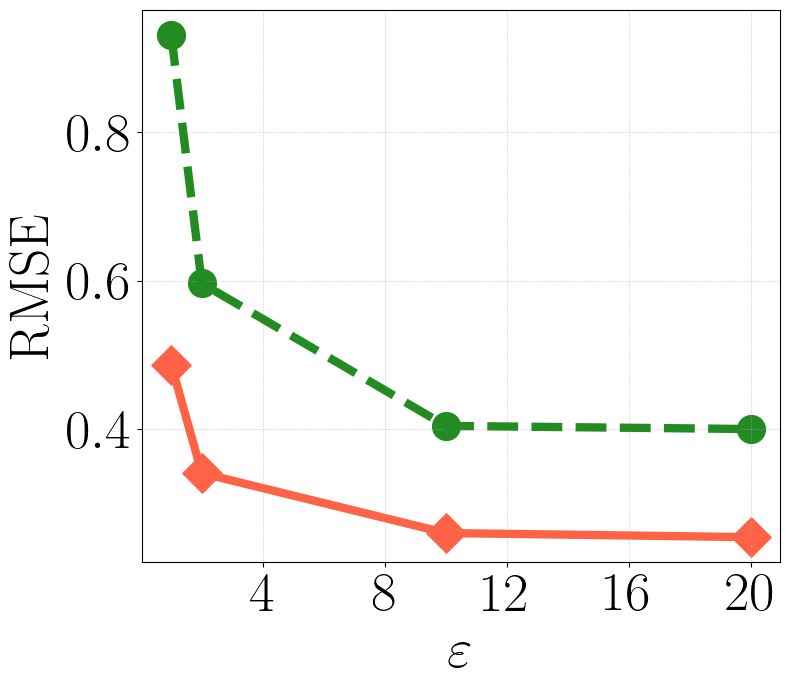

In [23]:
# observed entries
title = r'$\mathrm{Synthetic}~(p = 0.01)$'
#X = np.array([1000, 2000, 6000, 10000, 20000, 50000])
X = results['user_list']
epsilon_list = results['epsilon_list']
print(X)
print(epsilon_list)
"""
original_err_mean = results['original_err_mean']
original_err_std = results['original_err_std']
T_prob_err_mean = results['T_prob_err_mean']
T_prob_err_std = results['T_prob_err_std']
T_freq_err_mean = results['T_freq_err_mean']
T_freq_err_std = results['T_freq_err_std']
SVD_T_err_mean = results['SVD_T_err_mean']
SVD_T_err_std = results['SVD_T_err_std']
X_original_err_mean = results['X_original_err_mean']
X_original_err_std = results['X_original_err_std']
ob2_err_mean = results['ob2_err_mean']
ob2_rmse_mean = results['ob2_rmse_mean']
"""
rmse_mean = results['rmse_mean'].reshape(len(X), len(epsilon_list))
rmse_std = results['rmse_std'].reshape(len(X), len(epsilon_list))
ob2_err_mean = results['ob2_err_mean'].reshape(len(X), len(epsilon_list))
ob2_rmse_mean = results['ob2_rmse_mean'].reshape(len(X), len(epsilon_list))
err_mean = results['err_mean'].reshape(len(X), len(epsilon_list))
err_std = results['err_std'].reshape(len(X), len(epsilon_list))
#rmse_mean = results['rmse_mean']
#rmse_std = results['rmse_std'] 
plt.figure(figsize=(8,7))
i = 2
#plt.plot(X, original_err_mean, lw=4, label=r"$\tilde{M}^T\tilde{M}$")
#plt.plot(X, T_prob_err_mean, lw=4, label=r"$T_{\text{prob}}$")
#plt.plot(X, T_freq_err_mean, lw=4, label=r"$T_{\text{freq}}$")
#plt.plot(X, SVD_T_err_mean, lw=4, label=r"$\mathrm{SVD}$")
#plt.plot(X, ob2_rmse_mean[0], lw=4,linestyle='-.', label=r"$\|\cdot\|_\star~~\mathrm{reg.},~\epsilon=2$")
# plt.plot(epsilon_list, ob2_rmse_mean[1], lw=4,linestyle='-.')
plt.plot(epsilon_list[1:], ob2_rmse_mean[i][1:], lw=6,  color = "forestgreen",linestyle='dashed')
#plt.plot(X, rmse_mean[0], lw=4)
# plt.plot(epsilon_list, rmse_mean[1], lw=4)
plt.plot(epsilon_list[1:], rmse_mean[i][1:],  color='tomato', lw=6)

# plt.scatter(epsilon_list, ob2_rmse_mean[1], s=200,linestyle='-.', label=r"$\|\cdot\|_\star~~\mathrm{reg.},~d_1=1000$")
plt.scatter(epsilon_list[1:], ob2_rmse_mean[i][1:], s=400, color="forestgreen", label=r"$\mathrm{Nuclear~norm}$"+"\n"+r"$\mathrm{regularization}$")
#plt.scatter(X, rmse_mean[0], s=200, label=r"$\mathrm{Ours},~\epsilon=2$")
# plt.scatter(epsilon_list, rmse_mean[1], s=200, label=r"$\mathrm{Ours},~d_1=1000$")
plt.scatter(epsilon_list[1:], rmse_mean[i][1:], s=400, color='tomato',marker="D", label=r"$\mathrm{Alg.~1}$")


#plt.legend(fontsize=20, loc='upper center',bbox_to_anchor=(0.5, 1.4), ncol=2)
#plt.title(title, fontsize=40, y=1.4)
#plt.title(title, fontsize=40)
#plt.legend(fontsize=20, loc='center left',bbox_to_anchor=(1, 0.5), ncol=1)
#plt.legend(fontsize=30, loc='center right', ncol=1,bbox_to_anchor=(1, 0.4))

plt.xlabel(r"$\varepsilon$", fontsize=40)
plt.ylabel(r"$\mathrm{RMSE}$", fontsize=40)

plt.xticks(fontsize=40)
plt.yticks(fontsize=40)
#plt.yscale("log", base=10)
#plt.ylim(,1.1)
# plt.ticklabel_format(style='sci', axis='x', scilimits=(4, 4))
# plt.gca().xaxis.get_offset_text().set_fontsize(40)  

plt.gca().xaxis.set_major_locator(MaxNLocator(6))
plt.gca().yaxis.set_major_locator(MaxNLocator(4))
plt.grid(lw=0.5, ls=":")
#acc_str = f"best train acc: {np.array(train_acc).max():.4f}\nvalid acc: {val_acc[-1]:.4f}\nbest valid acc: {np.array(val_acc).max():.4f}\ngrokking gap: {val_converge-train_converge}"
# plt.annotate(acc_str, xy=(0.2, 0.5), xycoords='axes fraction', fontsize=12, color='purple', ha='center')
# add the annotation text to the overleaf file
plt.tight_layout()
plot_name = f"./plots/users_dp_5000_p2_rmse.pdf"
plt.savefig(plot_name, bbox_inches='tight', format="pdf", dpi=1200)

plt.show()
plt.close()